In [18]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

metrics_path = Path("runs/baseline/metrics.jsonl")

In [ ]:
import os
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts import train


In [ ]:
#Checking to make sure the records are storing the right things
records = []
with metrics_path.open("r", encoding="utf-8") as file:
    for line in file:
        if (line.strip()):
            record = json.loads(line)
            records.append(record)

print(records[0])
print(records[-1])

{'step': 1111, 'tokens': 2275328, 'train_loss': 5.773297309875488, 'val_loss': None, 'learning_rate': 3.0051863328339198e-05, 'gradient_norm': 0.9449995756149292}
{'step': 1120, 'tokens': 2293760, 'train_loss': 5.803620338439941, 'val_loss': 7.518791961669922, 'learning_rate': 3e-05, 'gradient_norm': 0.8980308175086975}


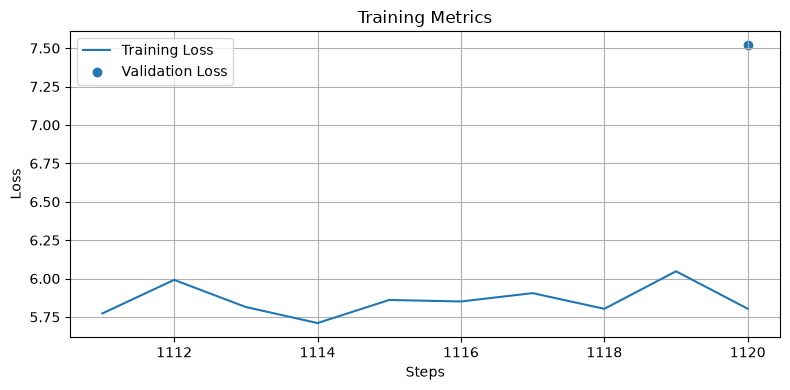

In [14]:
training_steps = [records[i]["step"] for i in range(len(records))]
training_loss = [records[i]["train_loss"] for i in range(len(records))]

validation_steps = [records[i]["step"] for i in range(len(records)) if records[i]["val_loss"] is not None]
validation_loss = [records[i]["val_loss"] for i in range(len(records)) if records[i]["val_loss"] is not None]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(
    training_steps,
    training_loss,
    label="Training Loss"
)
ax.scatter(
    validation_steps,
    validation_loss,
    label="Validation Loss"
)
ax.set_title("Training Metrics")
ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()
fig.tight_layout()

plt.show()

/tmp/ipykernel_110429/3813394443.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


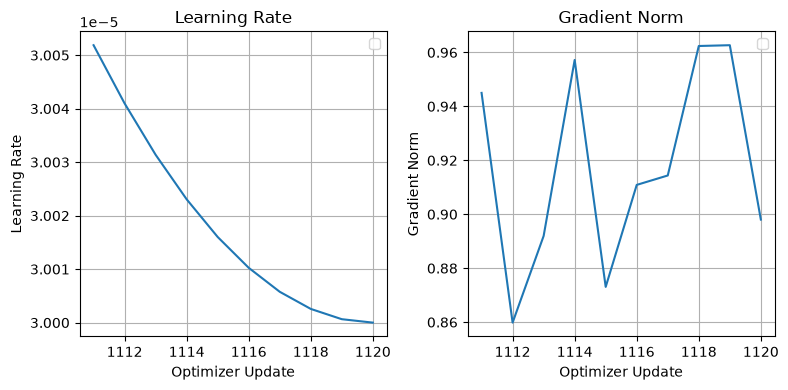

In [17]:
steps = [records[i]["step"] for i in range(len(records))]
learning_rate = [records[i]["learning_rate"] for i in range(len(records))]
gradient_norm = [records[i]["gradient_norm"] for i in range(len(records))]

fig, (lr_ax, grad_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

lr_ax.plot(steps, learning_rate,)
lr_ax.set(
    title="Learning Rate",
    xlabel="Optimizer Update",
    ylabel="Learning Rate",
)
grad_ax.plot(steps, gradient_norm,)
grad_ax.set(
    title="Gradient Norm",
    xlabel="Optimizer Update",
    ylabel="Gradient Norm",
)
for axis in (lr_ax, grad_ax):
    axis.grid(True)
    axis.legend()
    
fig.tight_layout()

plt.show()